# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV874"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv874')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv874/lv874-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV874,gene_band
0,ARHGDIA,7.485497,17q25.3
1,MOV10,5.774203,1p13.2
2,PDGFRB,4.003897,5q32
3,CALCOCO1,3.927307,12q13.13
4,MGAT1,3.638437,5q35.3
5,HYOU1,3.311395,11q23.3
6,FZD7,3.010703,2q33.1
7,PHB2,2.898367,12p13.31
8,CAMTA1,2.689559,1p36.31
9,GRK5,2.329162,10q26.11


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 14:53:31,056 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 14:53:31,057 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057205, SRP029367, SRP012461, SRP055569, SRP010038, SRP066834, SRP057196, SRP060416, SRP033135, SRP043166, SRP024268, SRP024244, SRP052056, SRP050499, SRP007461, SRP006474, SRP044042, SRP042161, SRP058773, SRP003901, SRP007481, SRP050374, SRP009862, SRP005279, SRP003726, SRP018853, SRP049409, SRP029656, SRP002487, SRP042218, SRP014867, SRP004847, SRP030617, SRP041573, SRP043162, SRP025982, SRP047192, SRP002079, SRP014856, SRP052706, SRP055153, SRP064458, SRP007947, SRP003021, SRP017972, SRP056498, SRP044206, SRP017575, SRP007359, SRP059379, SRP016140, SRP063840, SRP042184, SRP012607, SRP018020, SRP022892, SRP017142, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (55 != 57)
  warnings.warn(


In [12]:
lv_data.shape

(7409, 99)

In [13]:
lv_data.head()

cell line gfp cd13 ssea4 tra160 cell type treatment  \
project   run                                                                 
SRP057205 SRR1975508  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975507  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975506  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975505  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975503  Detroit 551   -   NA     +      +       NaN       NaN   

                     mov expression  day patient code name  ...  Sex  \
project   run                                               ...        
SRP057205 SRR1975508            NaN  NaN               NaN  ...  NaN   
          SRR1975507            NaN  NaN               NaN  ...  NaN   
          SRR1975506            NaN  NaN               NaN  ...  NaN   
          SRR1975505            NaN  NaN               NaN  ...  NaN   
          SRR1975503            NaN  NaN               NaN  ...  NaN   

                     age at diagnosis final gtf2i mutation status  \
project   run                                                       
SRP057205 SRR1975508              NaN                         NaN   
          SRR1975507              NaN                         NaN   
          SRR1975506              NaN                         NaN   
          SRR1975505              NaN                         NaN   
          SRR1975503              NaN                         NaN   

                     who histotype transfection storage method  \
project   run                                                    
SRP057205 SRR1975508           NaN          NaN            NaN   
          SRR1975507           NaN          NaN            NaN   
          SRR1975506           NaN          NaN            NaN   
          SRR1975505           NaN          NaN            NaN   
          SRR1975503           NaN          NaN            NaN   

                     purification method culture medium genotype/variation  \
project   run                                                                
SRP057205 SRR1975508                 NaN            NaN                NaN   
          SRR1975507                 NaN            NaN                NaN   
          SRR1975506                 NaN            NaN                NaN   
          SRR1975505                 NaN            NaN                NaN   
          SRR1975503                 NaN            NaN                NaN   

                         LV874  
project   run                   
SRP057205 SRR1975508  0.000223  
          SRR1975507  0.004690  
          SRR1975506  0.007838  
          SRR1975505  0.010443  
          SRR1975503  0.361580  

[5 rows x 99 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

gfp                    1.729947
cd13                   1.729947
ssea4                  1.729947
tra160                 1.729947
cell line              0.188884
mov expression         0.162371
treatment              0.009041
cell sorted            0.006557
time in culture        0.006557
overexpression         0.004630
protein                0.003067
enzymatic digestion    0.003067
clip variant           0.003067
patient                0.002960
passages               0.002738
cell type              0.002523
tumor stage            0.002159
pathology              0.002159
race                   0.002049
culture medium         0.001961
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line    0.188884
cell type    0.002523
tissue       0.001318
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "cell type",
    "tissue",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line  \
project   run                       
SRP057205 SRR1975480  Detroit 551   
          SRR1975479  Detroit 551   
          SRR1975494  Detroit 551   
          SRR1975493  Detroit 551   
SRP029367 SRR960459       HEK293F   
          SRR960461       HEK293F   
          SRR960460       HEK293F   
          SRR960462       HEK293F   
          SRR960463       HEK293F   
          SRR960464       HEK293F   
SRP057205 SRR1975455  Detroit 551   
          SRR1975456  Detroit 551   
          SRR1975463           H1   
          SRR1975464           H1   
          SRR1975473  Detroit 551   
          SRR1975474  Detroit 551   
SRP012461 SRR490412           NaN   
SRP055569 SRR2019172          NaN   
SRP057205 SRR1975457  Detroit 551   
          SRR1975458  Detroit 551   
          SRR1975477  Detroit 551   
          SRR1975478  Detroit 551   
          SRR1975504  Detroit 551   
          SRR1975503  Detroit 551   
          SRR1975465           H9   

                                                              cell type  \
project   run                                                             
SRP057205 SRR1975480                                                NaN   
          SRR1975479                                                NaN   
          SRR1975494                                                NaN   
          SRR1975493                                                NaN   
SRP029367 SRR960459                        Human Embryonic Kidney cells   
          SRR960461                        Human Embryonic Kidney cells   
          SRR960460                        Human Embryonic Kidney cells   
          SRR960462                        Human Embryonic Kidney cells   
          SRR960463                        Human Embryonic Kidney cells   
          SRR960464                        Human Embryonic Kidney cells   
SRP057205 SRR1975455                                                NaN   
          SRR1975456                                                NaN   
          SRR1975463                                                NaN   
          SRR1975464                                                NaN   
          SRR1975473                                                NaN   
          SRR1975474                                                NaN   
SRP012461 SRR490412                                         Fibroblasts   
SRP055569 SRR2019172  mixture of U87 human glioma cells and WI-38 hu...   
SRP057205 SRR1975457                                                NaN   
          SRR1975458                                                NaN   
          SRR1975477                                                NaN   
          SRR1975478                                                NaN   
          SRR1975504                                                NaN   
          SRR1975503                                                NaN   
          SRR1975465                                                NaN   

                     tissue     LV874  
project   run                          
SRP057205 SRR1975480    NaN  7.145822  
          SRR1975479    NaN  7.145625  
          SRR1975494    NaN  0.920045  
          SRR1975493    NaN  0.919606  
SRP029367 SRR960459     NaN  0.830622  
          SRR960461     NaN  0.830113  
          SRR960460     NaN  0.821582  
          SRR960462     NaN  0.820983  
          SRR960463     NaN  0.748539  
          SRR960464     NaN  0.739567  
SRP057205 SRR1975455    NaN  0.528382  
          SRR1975456    NaN  0.527711  
          SRR1975463    NaN  0.522837  
          SRR1975464    NaN  0.521473  
          SRR1975473    NaN  0.480429  
          SRR1975474    NaN  0.479731  
SRP012461 SRR490412     NaN  0.441866  
SRP055569 SRR2019172    NaN  0.422200  
SRP057205 SRR1975457    NaN  0.417292  
          SRR1975458    NaN  0.416320  
          SRR1975477    NaN  0.409184  
          SRR1975478    NaN  0.408183  
          SRR1975504    NaN  0.365405 

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

cell line  \
project   run                       
SRP057205 SRR1975466           H9   
SRP055569 SRR2018995          NaN   
          SRR1821439          NaN   
SRP057205 SRR1975459  Detroit 551   
SRP055569 SRR2018997          NaN   
SRP057205 SRR1975460  Detroit 551   
SRP010038 SRR392877           NaN   
SRP057205 SRR1975490  Detroit 551   
          SRR1975489  Detroit 551   
SRP055569 SRR1821566          NaN   
SRP066834 SRR2967480          NaN   
SRP010038 SRR392876           NaN   
SRP057196 SRR1974783          NaN   
SRP010038 SRR392874           NaN   
SRP060416 SRR2088328          NaN   
          SRR2088306          NaN   
SRP010038 SRR392898           NaN   
          SRR392878           NaN   
SRP033135 SRR1033243          NaN   
SRP057205 SRR1975475  Detroit 551   
          SRR1975476  Detroit 551   
SRP055569 SRR2019120          NaN   
SRP057205 SRR1975471  Detroit 551   
          SRR1975472  Detroit 551   
SRP060416 SRR2088254          NaN   

                                                              cell type  \
project   run                                                             
SRP057205 SRR1975466                                                NaN   
SRP055569 SRR2018995                             U87 human glioma cells   
          SRR1821439  mixture of U87 human glioma cells and MCF10a h...   
SRP057205 SRR1975459                                                NaN   
SRP055569 SRR2018997                             U87 human glioma cells   
SRP057205 SRR1975460                                                NaN   
SRP010038 SRR392877                                      Pterygia cells   
SRP057205 SRR1975490                                                NaN   
          SRR1975489                                                NaN   
SRP055569 SRR1821566  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967480                                                NaN   
SRP010038 SRR392876                                      Pterygia cells   
SRP057196 SRR1974783                                            neurons   
SRP010038 SRR392874                                      Pterygia cells   
SRP060416 SRR2088328                       tonsil Innate lymphoid cells   
          SRR2088306                       tonsil Innate lymphoid cells   
SRP010038 SRR392898                                      Pterygia cells   
          SRR392878                                      Pterygia cells   
SRP033135 SRR1033243             Human Skeletal Muscle Myoblasts (HSMM)   
SRP057205 SRR1975475                                                NaN   
          SRR1975476                                                NaN   
SRP055569 SRR2019120  mixture of U87 human glioma cells and WI-38 hu...   
SRP057205 SRR1975471                                                NaN   
          SRR1975472                                                NaN   
SRP060416 SRR2088254                       tonsil Innate lymphoid cells   

                                                                 tissue  \
project   run                                                             
SRP057205 SRR1975466                                                NaN   
SRP055569 SRR2018995                                                NaN   
          SRR1821439                                                NaN   
SRP057205 SRR1975459                                                NaN   
SRP055569 SRR2018997                                                NaN   
SRP057205 SRR1975460                                                NaN   
SRP010038 SRR392877                                                 NaN   
SRP057205 SRR1975490                                                NaN   
          SRR1975489                                                NaN   
SRP055569 SRR1821566                                                NaN   
SRP066834 SRR2967480  Microdissected cortical-like ventricle from ce...   
SRP010038 SRR392876    

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "tissue",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

cell line  \
project   run                                                             
SRP057205 SRR1975480                                        Detroit 551   
          SRR1975479                                        Detroit 551   
          SRR1975494                                        Detroit 551   
          SRR1975493                                        Detroit 551   
SRP029367 SRR960459                                             HEK293F   
          SRR960461                                             HEK293F   
          SRR960460                                             HEK293F   
          SRR960462                                             HEK293F   
          SRR960463                                             HEK293F   
          SRR960464                                             HEK293F   
SRP057205 SRR1975455                                        Detroit 551   
          SRR1975456                                        Detroit 551   
          SRR1975463                                                 H1   
          SRR1975464                                                 H1   
          SRR1975473                                        Detroit 551   
          SRR1975474                                        Detroit 551   
SRP012461 SRR490412                                         Fibroblasts   
SRP055569 SRR2019172  mixture of U87 human glioma cells and WI-38 hu...   
SRP057205 SRR1975457                                        Detroit 551   
          SRR1975458                                        Detroit 551   

                         LV874  
project   run                   
SRP057205 SRR1975480  7.145822  
          SRR1975479  7.145625  
          SRR1975494  0.920045  
          SRR1975493  0.919606  
SRP029367 SRR960459   0.830622  
          SRR960461   0.830113  
          SRR960460   0.821582  
          SRR960462   0.820983  
          SRR960463   0.748539  
          SRR960464   0.739567  
SRP057205 SRR1975455  0.528382  
          SRR1975456  0.527711  
          SRR1975463  0.522837  
          SRR1975464  0.521473  
          SRR1975473  0.480429  
          SRR1975474  0.479731  
SRP012461 SRR490412   0.441866  
SRP055569 SRR2019172  0.422200  
SRP057205 SRR1975457  0.417292  
          SRR1975458  0.416320

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['Detroit 551',
 'HEK293F',
 'H1',
 'Fibroblasts',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

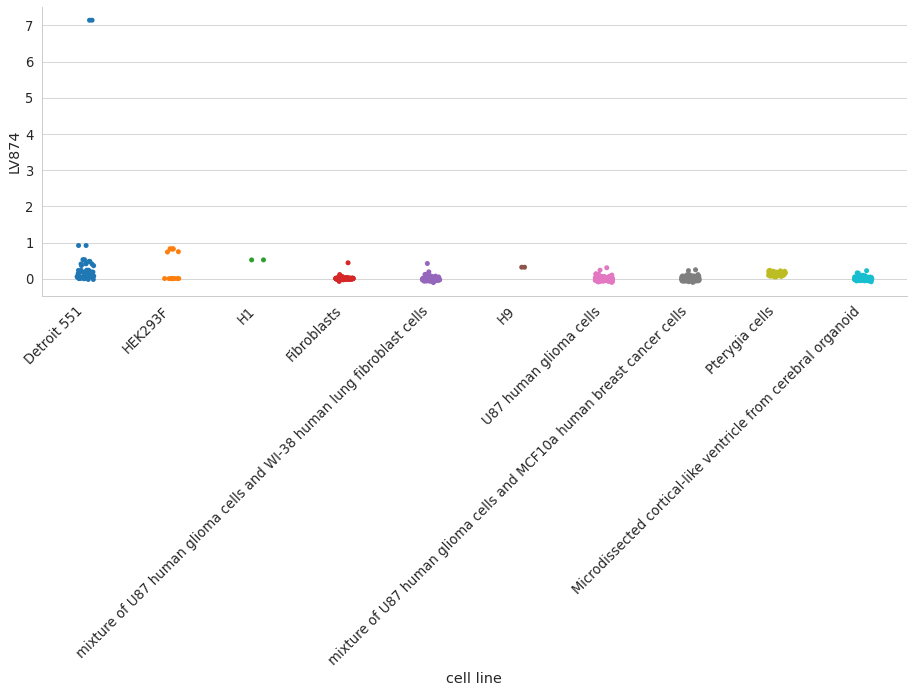

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("Detroit")
    ]
    display(_tmp.head(20))

cell line     LV874
project   run                              
SRP057205 SRR1975480  Detroit 551  7.145822
          SRR1975479  Detroit 551  7.145625
          SRR1975494  Detroit 551  0.920045
          SRR1975493  Detroit 551  0.919606
          SRR1975455  Detroit 551  0.528382
          SRR1975456  Detroit 551  0.527711
          SRR1975473  Detroit 551  0.480429
          SRR1975474  Detroit 551  0.479731
          SRR1975457  Detroit 551  0.417292
          SRR1975458  Detroit 551  0.416320
          SRR1975477  Detroit 551  0.409184
          SRR1975478  Detroit 551  0.408183
          SRR1975504  Detroit 551  0.365405
          SRR1975503  Detroit 551  0.361580
          SRR1975459  Detroit 551  0.237731
          SRR1975460  Detroit 551  0.236578
          SRR1975490  Detroit 551  0.233294
          SRR1975489  Detroit 551  0.231456
          SRR1975475  Detroit 551  0.193915
          SRR1975476  Detroit 551  0.191678

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV874
project   run                                                    
SRP057205 SRR1975480  Detroit 551   +    +     +     NA  7.145822
          SRR1975479  Detroit 551   +    +     +     NA  7.145625
          SRR1975494  Detroit 551   -   NA     +      +  0.920045
          SRR1975493  Detroit 551   -   NA     +      +  0.919606
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.528382
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.527711
          SRR1975463           H1  NA   NA    NA     NA  0.522837
          SRR1975464           H1  NA   NA    NA     NA  0.521473
          SRR1975473  Detroit 551   +    +    NA     NA  0.480429
          SRR1975474  Detroit 551   +    +    NA     NA  0.479731
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.417292
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.416320
          SRR1975477  Detroit 551   +    +     -     NA  0.409184
          SRR1975478  Detroit 551   +    +     -     NA  0.408183
          SRR1975504  Detroit 551   -   NA     +      +  0.365405
          SRR1975503  Detroit 551   -   NA     +      +  0.361580
          SRR1975465           H9  NA   NA    NA     NA  0.319867
          SRR1975466           H9  NA   NA    NA     NA  0.319864
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.237731
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.236578
          SRR1975490  Detroit 551   +   NA     +      -  0.233294
          SRR1975489  Detroit 551   +   NA     +      -  0.231456
          SRR1975475  Detroit 551   +    -     -     NA  0.193915
          SRR1975476  Detroit 551   +    -     -     NA  0.191678
          SRR1975471  Detroit 551   +    +    NA     NA  0.190481
          SRR1975472  Detroit 551   +    +    NA     NA  0.190401
          SRR1975487  Detroit 551   -   NA     +      -  0.185547
          SRR1975468         PGP1  NA   NA    NA     NA  0.183946
          SRR1975467         PGP1  NA   NA    NA     NA  0.182994
          SRR1975488  Detroit 551   -   NA     +      -  0.178383
          SRR1975481  Detroit 551   +    -     +     NA  0.142276
          SRR1975482  Detroit 551   +    -     +     NA  0.141954
          SRR1975469  Detroit 551   +    -    NA     NA  0.089477
          SRR1975470  Detroit 551   +    -    NA     NA  0.088974
          SRR1975499  Detroit 551   -   NA     +      -  0.073286
          SRR1975500  Detroit 551   -   NA     +      -  0.072839
          SRR1975495  Detroit 551   +   NA     -      -  0.071876
          SRR1975496  Detroit 551   +   NA     -      -  0.071729
          SRR1975491  Detroit 551   -   NA     +      +  0.061450
          SRR1975492  Detroit 551   -   NA     +      +  0.061157
          SRR1975485  Detroit 551   +   NA     -      -  0.051326
          SRR1975486  Detroit 551   +   NA     -      -  0.049432
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.049123
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.049008
          SRR1975501  Detroit 551   -   NA     +      +  0.044060
          SRR1975502  Detroit 551   -   NA     +      +  0.043984
          SRR1975498  Detroit 551   +   NA     +      -  0.038335
          SRR1975497  Detroit 551   +   NA     +      -  0.038302
          SRR1975484  Detroit 551   -    -     +     NA  0.018635
          SRR1975483  Detroit 551   -    -     +     NA  0.018549
          SRR1975505  Detroit 551  NA   NA    NA     NA  0.010443
          SRR1975506  Detroit 551  NA   NA    NA     NA  0.007838
          SRR1975507  Detroit 551  NA   NA    NA     NA  0.004690
          SRR1975508  Detroit 551  NA   NA    NA     NA  0.000223
          SRR1975462  Detroit 551  NA   NA    NA     NA -0.018291
          SRR1975461  Detroit 551  NA   NA    NA     NA -0.018472

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.